# Visualizing Categorical Variables

**Module 2: Data Visualization** | Lean Six Sigma Data Analytics

---

## Three Key Techniques

For categorical variables, the main visualization methods are:

| Technique | Best For |
|-----------|----------|
| Pie Chart | Proportions relative to total |
| Bar Chart | Comparing category frequencies |
| Tally Table | Exact counts and percentages |

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')

Data loaded successfully!


---

## Example: Bank Reclaims

**Context:** International money transfers sometimes have errors, leading to client reclaims.

**Questions:**
- Which type of reclaims occur most often?
- Which person handles the most reclaims?

In [2]:
# Load Reclaims data
reclaims = pd.read_excel(xlsx, sheet_name='Reclaims', skiprows=6, usecols=[0, 1, 2])
reclaims.columns = ['Reclaim_Type', 'Person', 'Processing_Time']
reclaims = reclaims.dropna()

print(f'Dataset: {reclaims.shape[0]} reclaims')
print(f'Reclaim Types: {reclaims["Reclaim_Type"].nunique()} unique')
print(f'People: {reclaims["Person"].nunique()} unique')
reclaims.head()

Dataset: 122 reclaims
Reclaim Types: 8 unique
People: 7 unique


,Reclaim_Type,Person,Processing_Time
0,Account closing,Jan sr.,24.89
1,IBAN,Marcel,27.36
2,Status info,Marcel,2.65
3,Matching,Margriet,23.48
4,Billing,Kees,35.92


---

## Pie Chart

A pie chart shows how often each category occurs as a proportion of the whole.

- **Total observations** form the complete pie
- **Each slice** represents one category
- **Slice size** = proportion of that category relative to total

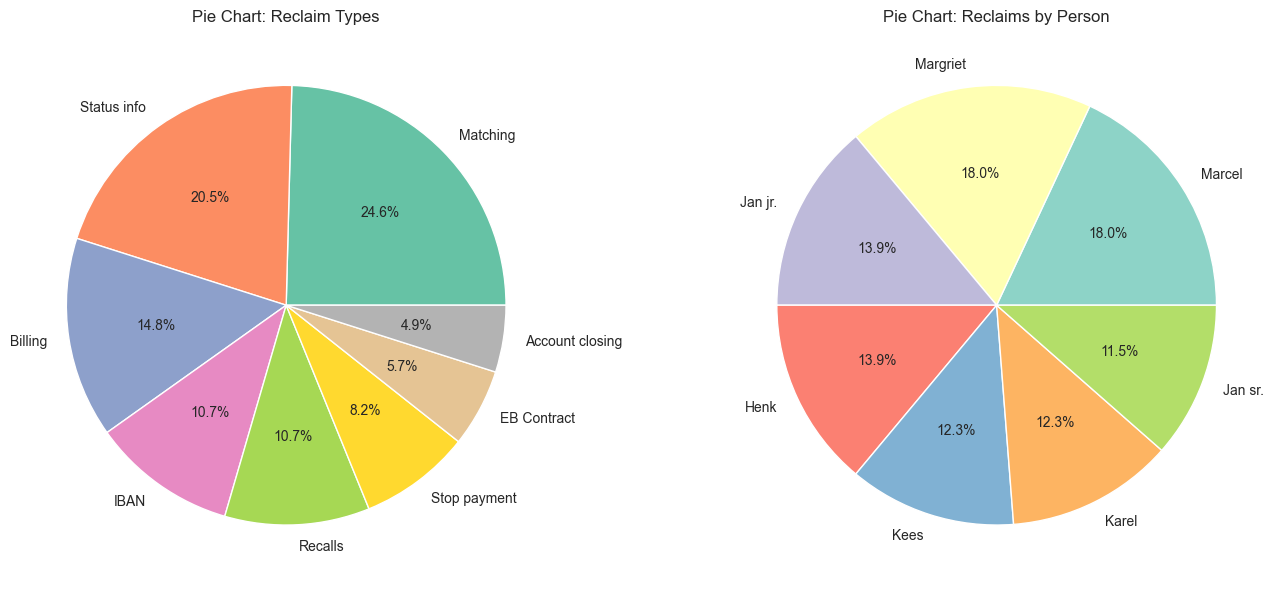

In [3]:
# Pie Chart - equivalent to Minitab: Graph > Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Reclaim Type
type_counts = reclaims['Reclaim_Type'].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette('Set2'))
axes[0].set_title('Pie Chart: Reclaim Types')

# Person
person_counts = reclaims['Person'].value_counts()
axes[1].pie(person_counts.values, labels=person_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3'))
axes[1].set_title('Pie Chart: Reclaims by Person')

plt.tight_layout()
plt.show()

### Limitation of Pie Charts

Can you tell which is larger—two similarly-sized slices? It's difficult to compare precise sizes visually. This is where bar charts excel.

---

## Bar Chart

A bar chart displays category frequencies using bar heights.

- **Horizontal axis:** The categories
- **Bar height:** Frequency (count of observations)

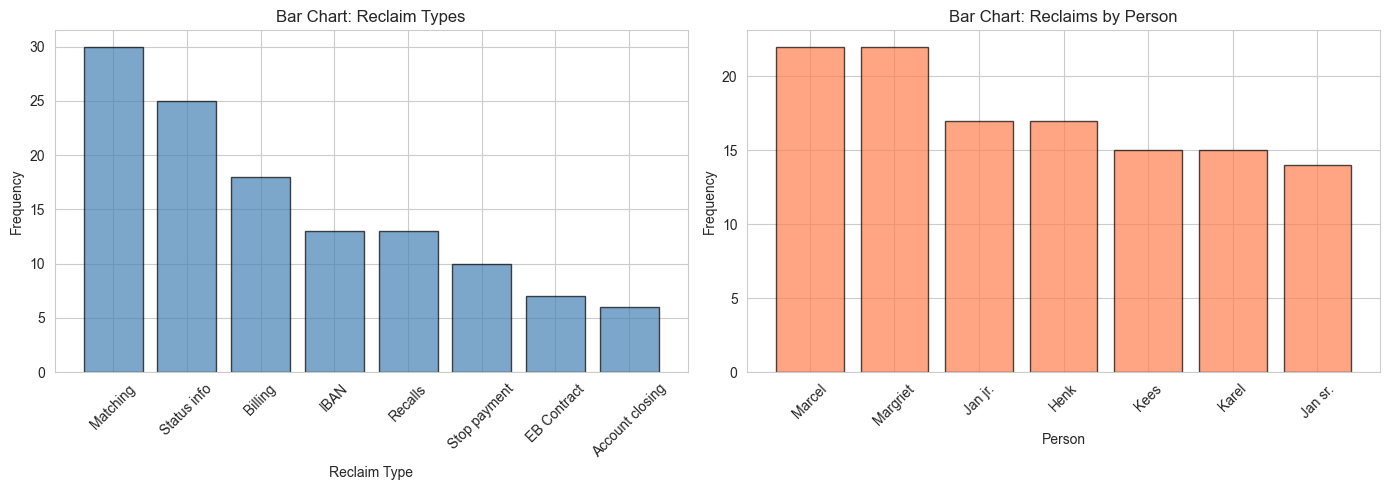

Most common reclaim type: Matching (30 occurrences)
Person handling most reclaims: Marcel (22 reclaims)


In [4]:
# Bar Chart - equivalent to Minitab: Graph > Bar Chart > Simple
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reclaim Type
type_counts = reclaims['Reclaim_Type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Reclaim Type')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Bar Chart: Reclaim Types')
axes[0].tick_params(axis='x', rotation=45)

# Person
person_counts = reclaims['Person'].value_counts()
axes[1].bar(person_counts.index, person_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Person')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Bar Chart: Reclaims by Person')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Most common reclaim type: {type_counts.index[0]} ({type_counts.values[0]} occurrences)')
print(f'Person handling most reclaims: {person_counts.index[0]} ({person_counts.values[0]} reclaims)')

### Advantages Over Pie Chart

| Aspect | Pie Chart | Bar Chart |
|--------|-----------|------------|
| Show proportions | Good | Good |
| Compare categories | Difficult | Easy |
| Spot largest category | Moderate | Easy |

---

## Tally Table

A tally table provides exact counts and percentages—the same information as the charts, but with precise numbers.

In [5]:
# Tally Table - equivalent to Minitab: Stat > Tables > Tally Individual Variables
def tally_table(series, name='Category'):
    """Create a tally table with counts and percentages."""
    counts = series.value_counts()
    tally = pd.DataFrame({
        name: counts.index,
        'Count': counts.values,
        'Percent': (counts.values / counts.sum() * 100).round(2)
    })
    tally['Cumulative %'] = tally['Percent'].cumsum().round(2)
    return tally

print('Tally Table: Reclaim Type')
print('=' * 50)
display(tally_table(reclaims['Reclaim_Type'], 'Reclaim_Type'))

Tally Table: Reclaim Type


,Reclaim_Type,Count,Percent,Cumulative %
0,Matching,30,24.59,24.59
1,Status info,25,20.49,45.08
2,Billing,18,14.75,59.83
3,IBAN,13,10.66,70.49
4,Recalls,13,10.66,81.15
5,Stop payment,10,8.20,89.35
6,EB Contract,7,5.74,95.09
7,Account closing,6,4.92,100.01


In [6]:
print('Tally Table: Person')
print('=' * 50)
display(tally_table(reclaims['Person'], 'Person'))

Tally Table: Person


,Person,Count,Percent,Cumulative %
0,Marcel,22,18.03,18.03
1,Margriet,22,18.03,36.06
2,Jan jr.,17,13.93,49.99
3,Henk,17,13.93,63.92
4,Kees,15,12.30,76.22
5,Karel,15,12.30,88.52
6,Jan sr.,14,11.48,100.00


---

## Pie vs Bar: When to Use Each

| Use Case | Recommended |
|----------|-------------|
| Emphasize part-of-whole relationships | Pie Chart |
| Compare category frequencies | Bar Chart |
| Many categories (>6) | Bar Chart |
| Need exact values | Tally Table |
| Quick visual overview | Either |

---

## Key Takeaways

- **Pie chart:** Shows proportions; each slice represents category's share of total
- **Bar chart:** Shows frequencies with bar heights; easier to compare categories
- **Tally table:** Provides exact counts and percentages
- All three techniques are for **categorical variables only**
- Choose based on your question: proportions (pie) vs. comparison (bar) vs. exact values (tally)